In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
from tqdm import tqdm
from matplotlib.colors import LogNorm
import pytz, cmath, itertools
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import scipy.sparse as ssp
from sympy import symbols
import utils_2Q_gate_zp as ut
import pandas as pd
import scipy as sp
from multiprocessing import Pool
import qutip as qt
import multiprocessing as mp
from multiprocessing import Pool
import scqubits as scq
from sympy import symbols
import scipy.sparse as ssp
from scipy.ndimage import gaussian_filter
import ham_data as hd
from datetime import datetime

In [2]:
# cz = pd.read_csv('data/data_cz_3ncut_truc1=300_select.txt')
# x0_vec = cz[['tg', 'drive_amp', 'detune']].to_numpy()#[[2, 9, -1],:]

# for i in x0_vec:
#     print(np.round(i,6).tolist(),',')

In [2]:
[tg,drive_amp,detune,f_300_200_True,f_300_1000_True] = [100.952316,0.015715,0.023862,-2.23997267,-2.12978291]
# [91.950393,0.01767,0.02547,-2.85663541,-2.87537611]
# [86.106856,0.019481,0.02577,-2.23547548,-2.21788608]
# [116.087948,0.012801,0.020071,-3.07740722,-3.08067203]
# [200.001076,0.006936,0.012052,-3.94183644,-3.90319705]
truc_full = 60
num_cpus = 16

# truc1, truc_tot, charge_pick = 300, 1000, False
# folder = f'../../data/3ncut_two_zeropi/truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
# hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()
# eval_tot = 2*np.pi* pd.read_csv(folder+ 'eval_tot.txt').to_numpy().flatten()
# n_theta1_dress = 2*np.pi* np.load(folder+'n_theta1_dress.npy')
# logi_state = ['0-0', '0-2', '2-0', '2-2']

folder_load = '../../data/_truc_3000'
[hspace_full, eket_tot, eval_tot, n_theta0_dress, n_theta1_dress, hspace_0, 
    hspace_1, logi_state] = hd.load_two_qubit_data(folder_load, return_full=False)  

eval_tot = eval_tot[:truc_full]
hspace_full = hspace_full[:truc_full]
n_theta1_dress = qt.Qobj(n_theta1_dress[np.ix_(np.arange(truc_full), np.arange(truc_full))])
logi_state_one = [0,2]
W_20_50 = eval_tot[hspace_full.index('5-0')] - eval_tot[hspace_full.index('2-0')]
H0 = qt.Qobj(np.diag(eval_tot))
logi_idx = [hspace_full.index(i) for i in logi_state]
H_qbt_drive = [H0, [n_theta1_dress, ut.drive_gauss_A] ]
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': W_20_50 + 2*np.pi*detune,
            'gate_time': tg}
tlist = np.linspace(0, tg, num=1*int(tg))  # total time
state_tot = [qt.basis(truc_full, i) for i in range(truc_full)]
state_interest = ['0-1', '1-0', '1-1',
                    '0-5', '1-2', '1-5',
                    '5-0', '2-1', '5-1',
                    '2-5', '5-2', '5-5']
max_step_ideal, max_step_noisy = 1e-3, 1e-3 # Set max_step to 0 for parallel execution
option_ideal, option_noisy = ut.get_qutip_options(max_step_ideal, max_step_noisy) 

ValueError: too many values to unpack (expected 8)

In [11]:
c_op_list = []
args_indep = [tg, drive_amp, detune]
args = [H_qbt_drive, W_20_50, num_cpus, c_op_list, logi_idx, option_ideal, option_noisy ]
f_ideal = ut.cz_fidelity_log_noise(args_indep, *args)
print(f'f_ideal (dim={truc_full})=', f_ideal)

f_ideal (dim=200)= -2.2399706955477603


In [6]:
result = {}
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive,
            qt.basis(truc_full, hspace_full.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_tot],
            args=pulse_args,
            options=qt.Options(store_states=True)  )


2it [00:06,  3.00s/it]
2it [00:03,  1.63s/it]


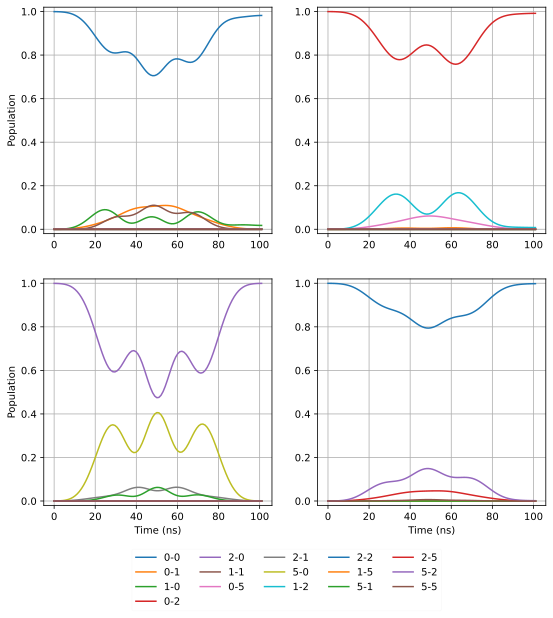

In [7]:
fig, ax = plt.subplots(figsize=(9,9), nrows=2, ncols=2)
for idx, state in enumerate(logi_state_one):
    for jdx, state in enumerate(logi_state_one):
        for kdx, res in zip(hspace_full, result[idx,jdx].expect):
            if kdx in logi_state + state_interest:
                ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
fig.legend(handles,labels, ncol=5,
            loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)

### save data

In [10]:
pop = np.array(result[0,0].expect)
print(np.shape(pop))
pop_integral = pop.sum(axis=1)
print(np.shape(pop_integral))

ut.top_population(np.array(result[0,0].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[0,1].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[1,0].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[1,1].expect).sum(axis=1), hspace_full)

(1000, 91)
(1000,)

Top 10 values: [76.43218609909326, 5.120352318665643, 4.4196992285573735, 4.181719014511284, 0.48324191907911734, 0.15097985316590282, 0.1199970255024042, 0.05940401800025817, 0.014526718336313941, 0.01001263143180157]
State of large population: ['0-0' '0-1' '1-1' '1-0' '4-1' '0-4' '4-0' '1-4' '4-4' '8-0']

Top 10 values: [78.16007309876518, 8.73883041018719, 2.6135322087463866, 1.0384706927215124, 0.3233507223674746, 0.023315200770869158, 0.01746222066719063, 0.016424747858562287, 0.011593627393864922, 0.010574707131735165]
State of large population: ['0-2' '1-2' '0-5' '4-2' '1-5' '1-12' '4-5' '0-9' '0-12' '8-21']

Top 10 values: [67.08633073647138, 18.6619773395384, 2.9136089568705086, 1.9842279437018244, 0.1587343166741626, 0.11174548608608445, 0.062299507751119476, 0.015350308244859463, 0.004140648965867342, 0.0006704010478156586]
State of large population: ['2-0' '5-0' '2-1' '5-1' '2-4' '9-0' '5-4' '9-1' '2-8' '9-4']

Top 10 values: [81.89920040544067, 6.399988

In [19]:
def top_population(pop_integral, hspace_full, num=10):
    arr = pop_integral
    # Get the indices of the top 10 largest values
    top_indices = np.argsort(arr)[-num:]  # Sort and take the last 10 indices
    # Get the top 10 largest values
    top_values = arr[top_indices]
    # Sorting in descending order (optional)
    sorted_order = np.argsort(top_values)[::-1]
    top_indices = top_indices[sorted_order]
    top_values = np.round(top_values[sorted_order] / np.sum(top_values), 4)
    print("\nTop 10 values:", top_values.tolist())
    print("State of large population:", np.array(hspace_full)[top_indices.tolist()])
    return None

top_population(np.array(result[1,0].expect).sum(axis=1), hspace_full)



Top 10 values: [0.7372, 0.2051, 0.032, 0.0218, 0.0017, 0.0012, 0.0007, 0.0002, 0.0, 0.0]
State of large population: ['2-0' '5-0' '2-1' '5-1' '2-4' '9-0' '5-4' '9-1' '2-8' '9-4']


In [20]:
1-0.7372

0.26280000000000003

In [11]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
idx_00 = [hspace_full.index(i) for i in ['0-0', '0-1', '1-1', '1-0']]
idx_02 = [hspace_full.index(i) for i in ['0-2', '1-2', '0-5']]
idx_20 = [hspace_full.index(i) for i in ['2-0', '5-0', '2-1', '5-1']]
idx_22 = [hspace_full.index(i) for i in ['2-2', '5-2', '2-5']]

col_00 = ['tg'] + ['0-0', '0-1', '1-1', '1-0'] + ['other']
col_02 = ['tg'] + ['0-2', '1-2', '0-5'] + ['other']
col_20 = ['tg'] + ['2-0', '5-0', '2-1', '5-1'] + ['other']
col_22 = ['tg'] + ['2-2', '5-2', '2-5'] + ['other']

state_interest_vec = [idx_00, idx_02, idx_20, idx_22]
col_vec = [col_00, col_02, col_20, col_22]
pop_vec = [np.array(result[0,0].expect)
        , np.array(result[0,1].expect)
        , np.array(result[1,0].expect)
        , np.array(result[1,1].expect)]
for i in range(4):
    state_interest = state_interest_vec[i]
    pop = pop_vec[i]
    pop_interest = pop[state_interest, :]
    pop_other = np.delete(pop, state_interest, axis=0).sum(axis=0)
    pop_save = np.vstack((tlist,pop_interest, pop_other)).T

    df = pd.DataFrame(pop_save, columns=col_vec[i])
    # df.to_csv(f'data/cz_population_tg={int(tg)}_{col_vec[i][1][0] + col_vec[i][1][2]}_3ncut.txt', sep=',', index=False, header=True)

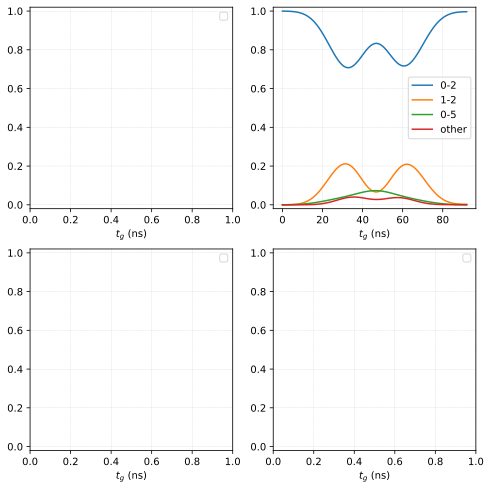

In [ ]:
pop_02 = pd.read_csv('data/cz_population_02_3ncut_tg=91.txt').to_numpy()
x_size, y_size = 8, 8
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(x_size, y_size))
for i in np.arange(1, pop_02.shape[1]):
    ax[0][1].plot( pop_02[:,0], gaussian_filter( pop_02[:,i], 3), '-', label=col_02[i])
for i in range(2):
    for j in range(2):
        # ax[i].set_xlim(-25, 25)
        ax[i][j].set_ylim(-0.02, 1.02)
        ax[i][j].legend()
        ax[i][j].grid(linewidth=0.2, linestyle='--')
        ax[i][j].set_xlabel(r'$t_g$ (ns)')

In [ ]:
=

In [ ]:
# fig, ax = plt.subplots(figsize=(10,10), nrows=2, ncols=2)
# order = ['(a)', '(b)','(c)','(d)']
# for idx, state_i in enumerate(logi_state_one):
#     for jdx, state_j in enumerate(logi_state_one):
#         for kdx, res in zip(hspace_full, result[idx,jdx].expect):
#             ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
#         ax[idx][jdx].set_ylim(-0.02,1.02)
#         ax[idx][jdx].grid()
#     ax[1][idx].set_xlabel('Time (ns)')
#     ax[idx][0].set_ylabel('Population')
# handles, labels = ax[1][1].get_legend_handles_labels()
# fig.legend(handles,labels, ncol=5,
#             loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)

#### cz_fidelity_sensivity

In [ ]:

detune_vec = np.linspace(-0.025, 0.025, 101)
values_grid = list(itertools.product(detuning + detune_vec, [drive_amp], [d_eta]))
fidelity_wd = Parallel(n_jobs=len(detune_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

A_vec = np.linspace(-0.025, 0.025, 101)
values_grid = list(itertools.product([detuning], drive_amp+A_vec, [d_eta]))
fidelity_A = Parallel(n_jobs=len(A_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

eta_vec = np.linspace(-0.05, 0.05, 101)
values_grid = list(itertools.product([detuning], [drive_amp], d_eta+eta_vec))
fidelity_eta = Parallel(n_jobs=len(eta_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.3s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    1.9s finished
[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.2s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    1.9s finished
[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.3s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    2.1s finished


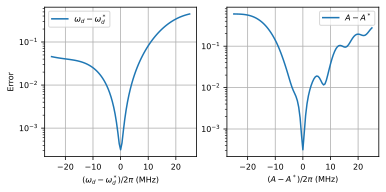

In [ ]:
error_vs_dwd = np.column_stack((np.round(10**3 * detune_vec, 2), np.round(fidelity_wd, 8)))
columns = ['dwd_vec(MHz)',  'error_wd']
df = pd.DataFrame(error_vs_dwd, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_dwd.txt', sep=',', index=True, header=True)

# error_vs_A = np.column_stack((np.round(10**3 * A_vec, 2), np.round(fidelity_A, 8)))
# columns = ['dA_vec(MHz)',  'error_A']
# df = pd.DataFrame(error_vs_A, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_dA.txt', sep=',', index=True, header=True)

# error_vs_eta = np.column_stack((np.round( eta_vec, 2), np.round(fidelity_eta, 8)))
# columns = ['eta_vec',  'error_A']
# df = pd.DataFrame(error_vs_eta, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_eta.txt', sep=',', index=True, header=True)

df_wd = pd.read_csv('data/cz_dark_tg90_error_vs_dwd.txt')
df_dA = pd.read_csv('data/cz_dark_tg90_error_vs_dA.txt')
df_eta = pd.read_csv('data/cz_dark_tg90_error_vs_eta.txt')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,2.7))
ax[0].plot( df_wd['dwd_vec(MHz)'], 10**df_wd['error_wd'], '-', label='$\omega_{d} - \omega_{d}^*$')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$(\omega_{d} - \omega_{d}^*)/2\pi$ (MHz)')
ax[0].set_ylabel('Error')
ax[0].grid()
ax[0].legend()

ax[1].plot( df_dA['dA_vec(MHz)'], 10**df_dA['error_A'], '-', label='$A - A^*$')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$(A - A^*)/2\pi$ (MHz)')
ax[1].grid()
ax[1].legend()
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')